In [2]:
import pandas as pd

data = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print(data.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

TRAIN PERFORMANCE
Accuracy: 0.8630952380952381
Confusion Matrix:
 [[866 112]
 [ 49 149]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.89      0.91       978
           1       0.57      0.75      0.65       198

    accuracy                           0.86      1176
   macro avg       0.76      0.82      0.78      1176
weighted avg       0.88      0.86      0.87      1176



TEST PERFORMANCE
Accuracy: 0.7619047619047619
Confusion Matrix:
 [[207  48]
 [ 22  17]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.86       255
           1       0.26      0.44      0.33        39

    accuracy                           0.76       294
   macro avg       0.58      0.62      0.59       294
weighted avg       0.82      0.76      0.79       294


Feature Importance:

OverTime                    0.261562
TotalWorkingYears           0.111524
JobLevel               

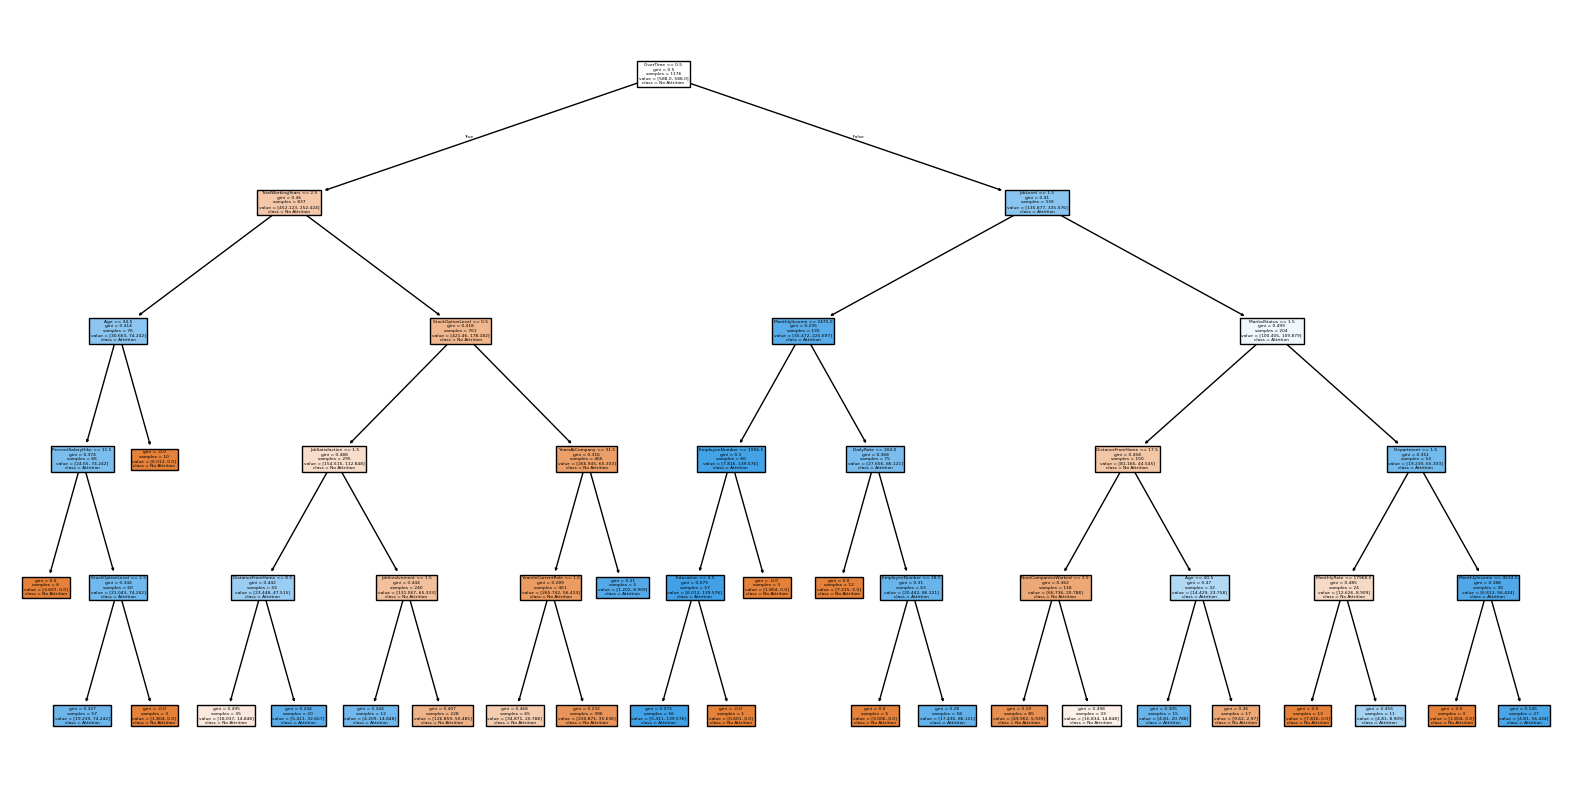

In [6]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# -------------------------------
# Encode categorical variables
# -------------------------------

data_encoded = data.copy()

label_encoder = LabelEncoder()

for col in data_encoded.columns:
    if data_encoded[col].dtype == 'object':
        data_encoded[col] = label_encoder.fit_transform(data_encoded[col])

# -------------------------------
# Define features and target
# -------------------------------

X = data_encoded.drop("Attrition", axis=1)
y = data_encoded["Attrition"]

# -------------------------------
# Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Train Decision Tree
# -------------------------------

model = DecisionTreeClassifier(
    max_depth=5,      # keeps tree readable
    random_state=4,
    class_weight="balanced",
    min_samples_split=12
)

model.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# -------------------------------
# Performance Metrics
# -------------------------------

print("TRAIN PERFORMANCE")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_pred))
print("Classification Report:\n", classification_report(y_train, train_pred))

print("\n=============================\n")

print("TEST PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("Classification Report:\n", classification_report(y_test, test_pred))

# -------------------------------
# Feature Importance
# -------------------------------

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nFeature Importance:\n")
print(importance)

# -------------------------------
# Plot Decision Tree
# -------------------------------

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Attrition","Attrition"],
    filled=True
)

plt.show()

TRAIN PERFORMANCE
Accuracy: 0.8775510204081632
Confusion Matrix:
 [[768  95]
 [ 31 135]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92       863
           1       0.59      0.81      0.68       166

    accuracy                           0.88      1029
   macro avg       0.77      0.85      0.80      1029
weighted avg       0.90      0.88      0.89      1029



TEST PERFORMANCE
Accuracy: 0.7777777777777778
Confusion Matrix:
 [[308  62]
 [ 36  35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.83      0.86       370
           1       0.36      0.49      0.42        71

    accuracy                           0.78       441
   macro avg       0.63      0.66      0.64       441
weighted avg       0.81      0.78      0.79       441


Feature Importance:

YearsAtCompany              0.111757
YearsWithCurrManager        0.087177
StockOptionLevel       

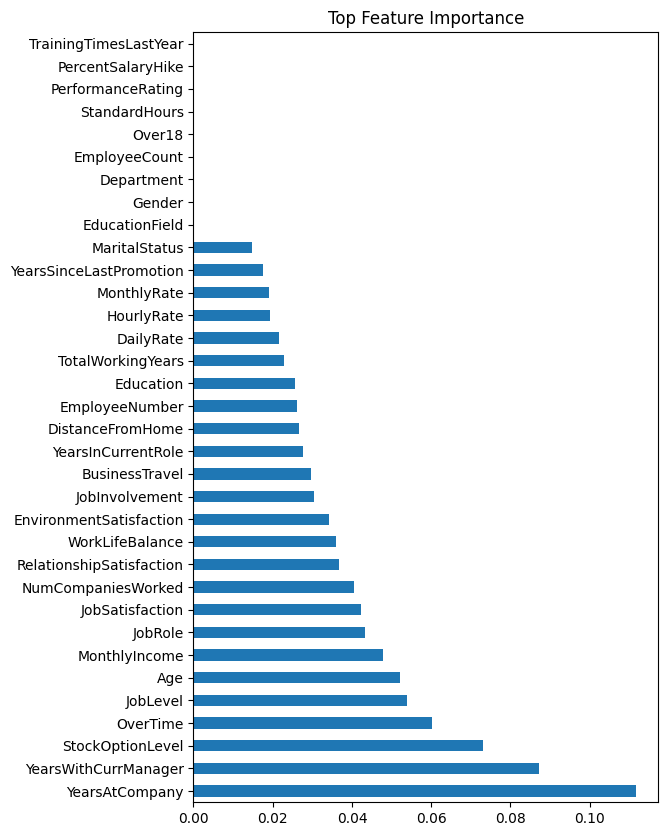

In [11]:
# Import libraries
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# -----------------------------------
# Encode categorical variables
# -----------------------------------

data_encoded = data.copy()

le = LabelEncoder()

for col in data_encoded.columns:
    if data_encoded[col].dtype == 'object':
        data_encoded[col] = le.fit_transform(data_encoded[col])

# -----------------------------------
# Features and Target
# -----------------------------------

X = data_encoded.drop("Attrition", axis=1)
y = data_encoded["Attrition"]

# -----------------------------------
# Train Test Split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -----------------------------------
# Handle Imbalance
# -----------------------------------

pos = sum(y_train == 1)
neg = sum(y_train == 0)

scale_pos_weight = neg / pos

# -----------------------------------
# Train XGBoost Model
# -----------------------------------

model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=50,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# -----------------------------------
# Predictions
# -----------------------------------

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# -----------------------------------
# Train Performance
# -----------------------------------

print("TRAIN PERFORMANCE")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_pred))
print("Classification Report:\n", classification_report(y_train, train_pred))

print("\n============================\n")

# -----------------------------------
# Test Performance
# -----------------------------------

print("TEST PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("Classification Report:\n", classification_report(y_test, test_pred))

# -----------------------------------
# Feature Importance
# -----------------------------------

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nFeature Importance:\n")
print(importance)

# -----------------------------------
# Plot Feature Importance
# -----------------------------------

plt.figure(figsize=(6,10))
importance.head(35).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

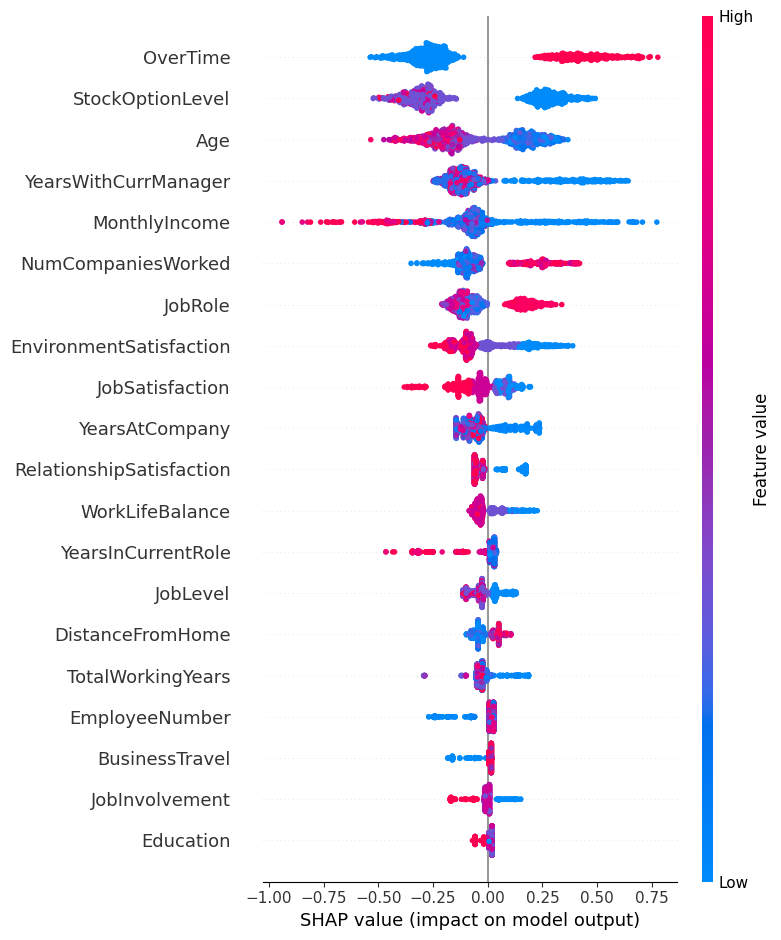

In [10]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_train)

# --------------------------------
# SHAP Summary Plot
# --------------------------------

shap.summary_plot(shap_values, X_train)
